# 02 — Person Detection
YOLOv8 pretrained on COCO, run on Mall dataset frames.

In [12]:
import csv
import time
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.io import loadmat
from ultralytics import YOLO

sns.set_theme(style="whitegrid")

In [13]:
RAW = Path('../data/raw')
frame_path = RAW / 'frames/seq_000001.jpg'

model = YOLO('yolov8n.pt')  # downloads ~6MB to ultralytics cache on first run
results = model(frame_path)


image 1/1 /Users/kcholys/Repositories/Mall-heatmap/notebooks/../data/raw/frames/seq_000001.jpg: 480x640 20 persons, 1 suitcase, 29.6ms
Speed: 0.6ms preprocess, 29.6ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


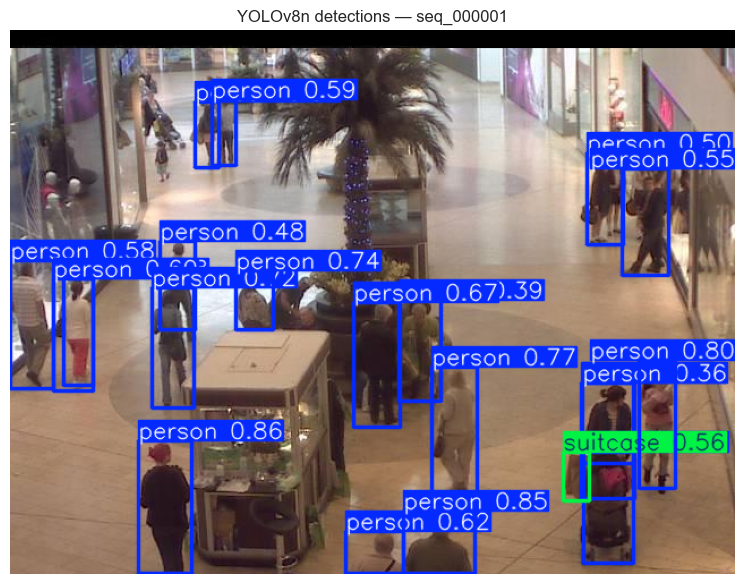

In [14]:
# results[0].plot() returns a BGR numpy array with boxes + labels drawn
annotated = results[0].plot()

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(annotated[..., ::-1])  # BGR → RGB
ax.axis('off')
ax.set_title('YOLOv8n detections — seq_000001')
plt.tight_layout()
plt.show()


image 1/1 /Users/kcholys/Repositories/Mall-heatmap/notebooks/../data/raw/frames/seq_000001.jpg: 480x640 20 persons, 29.7ms
Speed: 0.6ms preprocess, 29.7ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
Total detections (all classes):  21
Person-only detections:          20


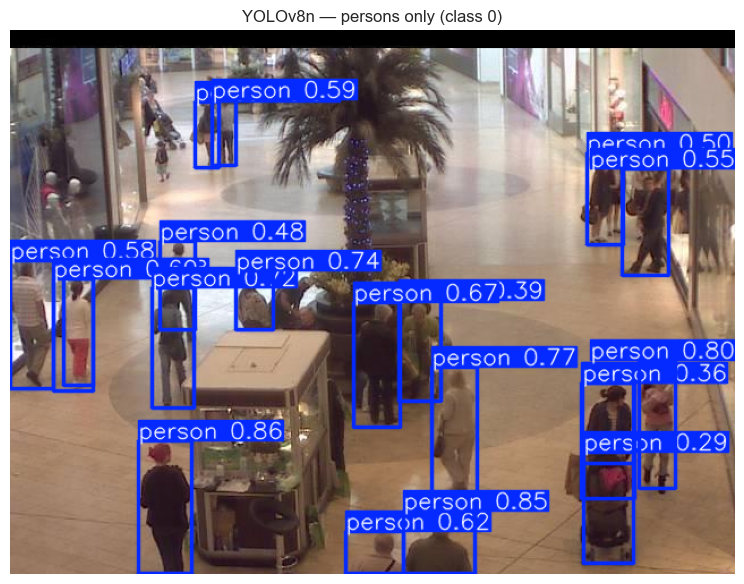

In [15]:
# class 0 = person in COCO; classes=[0] suppresses all other categories
results_persons = model(frame_path, classes=[0])

print(f'Total detections (all classes):  {len(results[0].boxes)}')
print(f'Person-only detections:          {len(results_persons[0].boxes)}')

annotated_persons = results_persons[0].plot()

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(annotated_persons[..., ::-1])
ax.axis('off')
ax.set_title('YOLOv8n — persons only (class 0)')
plt.tight_layout()
plt.show()


Extracted 20 bottom-centre coordinates
Sample (x, y):
[[      137.4       479.7]
 [      378.6       479.7]
 [      571.7       404.3]
 [      392.5       412.3]
 [      215.6       264.3]]


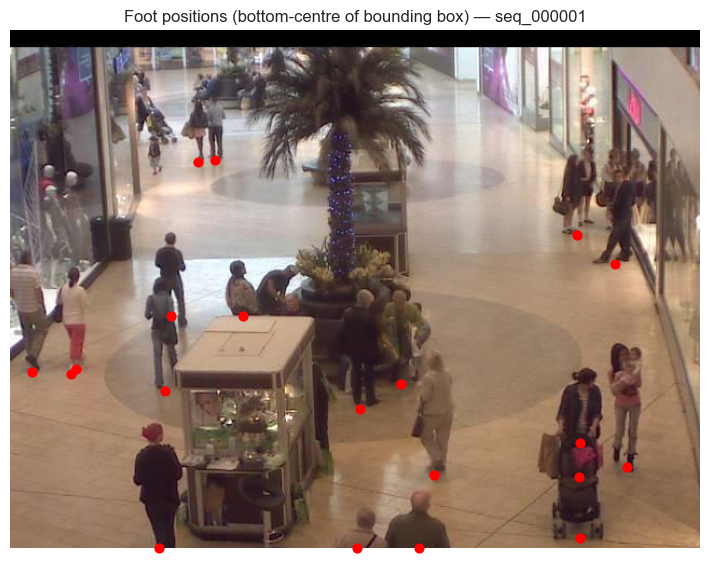

In [16]:
# xyxy format: [x1, y1, x2, y2] — bottom-centre = (midpoint of x, y2)
boxes = results_persons[0].boxes.xyxy.cpu().numpy()
bottom_centres = np.column_stack([
    (boxes[:, 0] + boxes[:, 2]) / 2,
    boxes[:, 3]
])

print(f'Extracted {len(bottom_centres)} bottom-centre coordinates')
print('Sample (x, y):')
print(bottom_centres[:5].round(1))

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(mpimg.imread(str(frame_path)))
ax.scatter(bottom_centres[:, 0], bottom_centres[:, 1], c='red', s=40, zorder=5)
ax.axis('off')
ax.set_title('Foot positions (bottom-centre of bounding box) — seq_000001')
plt.tight_layout()
plt.show()

## Batch detection across all frames

In [17]:
all_frames = sorted(RAW.glob('frames/seq_*.jpg'))
out_path = Path('../data/interim/detections.csv')

t0 = time.time()
with open(out_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['frame_id', 'x', 'y', 'confidence'])

    for i, path in enumerate(all_frames):
        frame_id = int(path.stem.replace('seq_', ''))
        res = model(path, classes=[0], verbose=False)
        for box in res[0].boxes:
            x = float((box.xyxy[0, 0] + box.xyxy[0, 2]) / 2)
            y = float(box.xyxy[0, 3])
            conf = float(box.conf[0])
            writer.writerow([frame_id, round(x, 2), round(y, 2), round(conf, 4)])

        if (i + 1) % 200 == 0:
            print(f'Processed {i + 1}/2000 frames ({time.time() - t0:.0f}s elapsed)')

elapsed = time.time() - t0
print(f'Done. {elapsed:.0f}s total ({elapsed / len(all_frames) * 1000:.0f}ms per frame)')

Processed 200/2000 frames (6s elapsed)
Processed 400/2000 frames (11s elapsed)
Processed 600/2000 frames (16s elapsed)
Processed 800/2000 frames (21s elapsed)
Processed 1000/2000 frames (26s elapsed)
Processed 1200/2000 frames (31s elapsed)
Processed 1400/2000 frames (37s elapsed)
Processed 1600/2000 frames (42s elapsed)
Processed 1800/2000 frames (47s elapsed)
Processed 2000/2000 frames (52s elapsed)
Done. 52s total (26ms per frame)


In [18]:
data = np.loadtxt(out_path, delimiter=',', skiprows=1)
print(f'Total detections:     {len(data)}')
print(f'Unique frames:        {len(np.unique(data[:, 0]).astype(int))}')
print(f'Detections per frame: min={int(np.min(np.bincount(data[:, 0].astype(int))[1:]))}, '
      f'max={int(np.max(np.bincount(data[:, 0].astype(int))[1:]))}, '
      f'mean={np.mean(np.bincount(data[:, 0].astype(int))[1:]):.1f}')
print(f'Confidence range:     {data[:, 3].min():.2f} – {data[:, 3].max():.2f}')
print('\nFirst 5 rows (frame_id, x, y, confidence):')
print(data[:5])

Total detections:     36014
Unique frames:        2000
Detections per frame: min=4, max=34, mean=18.0
Confidence range:     0.25 – 0.92

First 5 rows (frame_id, x, y, confidence):
[[          1      137.38      479.68      0.8554]
 [          1      378.64      479.68       0.847]
 [          1      571.75      404.27      0.8049]
 [          1      392.54      412.26      0.7715]
 [          1      215.64      264.25      0.7378]]


## Detection counts vs ground truth

MAE: 13.15 persons/frame


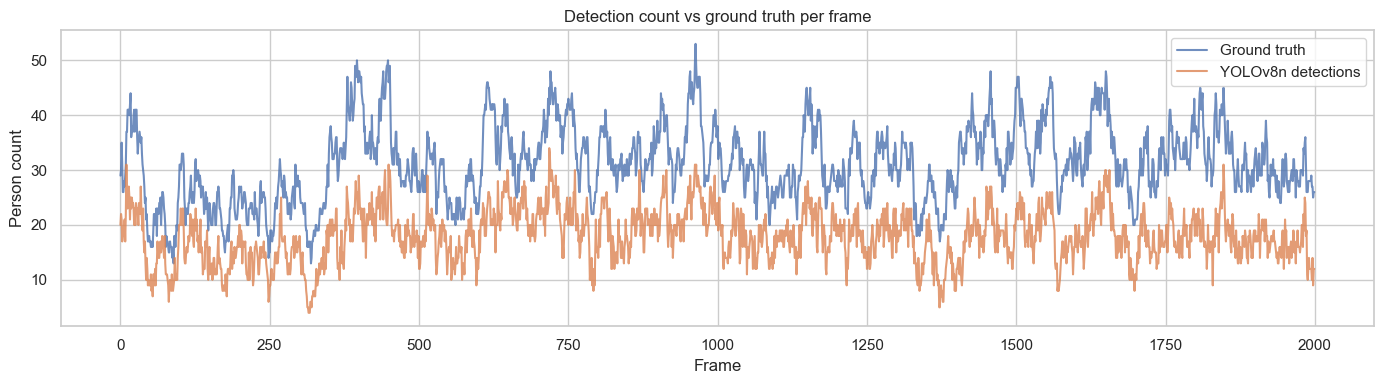

In [19]:
gt = loadmat(RAW / 'mall_gt.mat')
gt_counts = gt['count'].flatten()

detections_path = Path('../data/interim/detections.csv')
data = np.loadtxt(detections_path, delimiter=',', skiprows=1)
det_counts = np.bincount(data[:, 0].astype(int), minlength=2001)[1:]

mae = np.mean(np.abs(det_counts - gt_counts))
print(f'MAE: {mae:.2f} persons/frame')

fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(x=range(len(gt_counts)), y=gt_counts, label='Ground truth', alpha=0.8, ax=ax)
sns.lineplot(x=range(len(det_counts)), y=det_counts, label='YOLOv8n detections', alpha=0.8, ax=ax)
ax.set_xlabel('Frame')
ax.set_ylabel('Person count')
ax.set_title('Detection count vs ground truth per frame')
plt.tight_layout()
plt.show()

In [20]:
diff = det_counts - gt_counts

stats = {
    'Metric':  ['Median', 'Min', 'Max'],
    'YOLO':    [int(np.median(det_counts)), int(det_counts.min()), int(det_counts.max())],
    'GT':      [int(np.median(gt_counts)),  int(gt_counts.min()),  int(gt_counts.max())],
    'Diff (YOLO - GT)': [int(np.median(diff)), int(diff.min()), int(diff.max())],
}

col_w = 18
header = ''.join(f'{k:<{col_w}}' for k in stats)
print(header)
print('-' * len(header))
for i in range(len(stats['Metric'])):
    print(''.join(f'{stats[k][i]:<{col_w}}' for k in stats))


Metric            YOLO              GT                Diff (YOLO - GT)  
------------------------------------------------------------------------
Median            18                31                -13               
Min               4                 13                -29               
Max               34                53                -3                


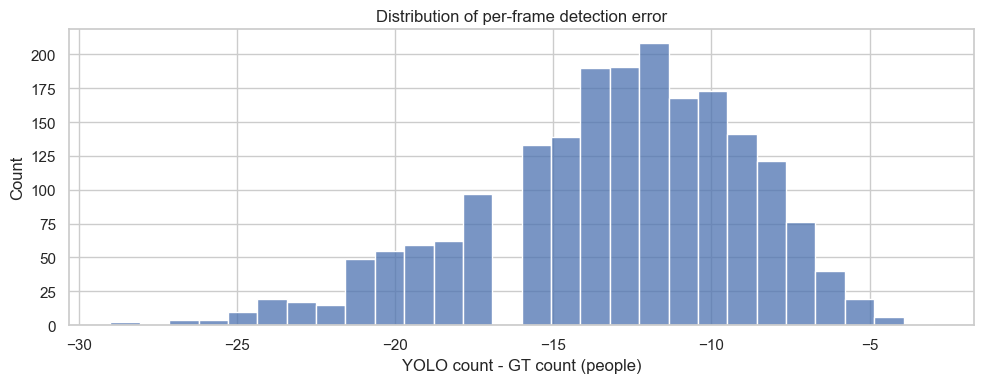

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(diff, fill=True, ax=ax)
ax.set_xlabel('YOLO count - GT count (people)')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-frame detection error')
plt.tight_layout()
plt.show()

## Visual comparison - YOLO vs ground truth

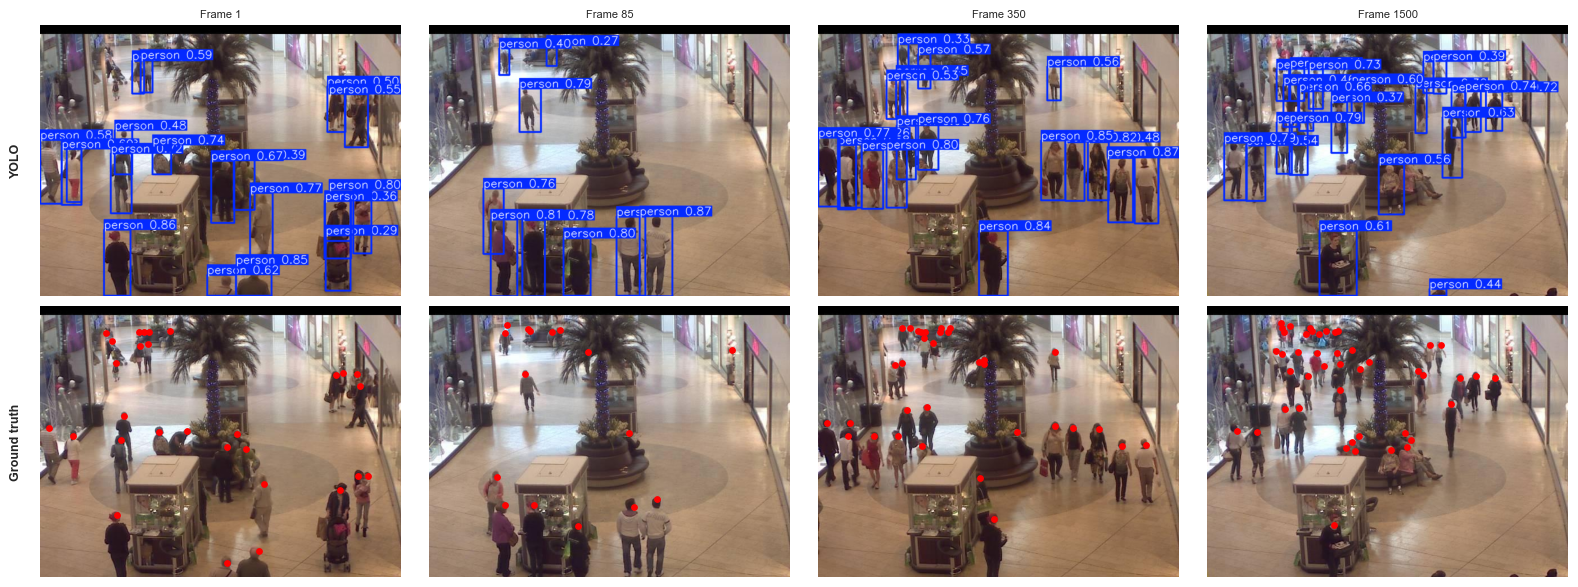

In [22]:
import sys
sys.path.insert(0, '..')

from src.plots import view_detections

gt = loadmat(RAW / 'mall_gt.mat')
view_detections([1, 85, 350, 1500], model, RAW / 'frames', gt)